# Notebook 06 _ Évaluation finale des modèles

## Objectif

Ce notebook est consacré à l'évaluation finale des modèles sélectionnés lors
du Notebook 05.

Les modèles sauvegardés sont appliqués à l'ensemble de test, qui n'a jamais
été utilisé pendant l'entraînement ni pendant la sélection des modèles.

Les principales étapes sont :

- chargement des modèles entraînés ;
- reconstruction du jeu de test ;
- calcul des métriques finales ;
- comparaison des performances ;
- visualisation des prédictions ;
- analyse des erreurs ;
- interprétation des résultats.

Les performances obtenues dans ce notebook constituent les résultats finaux
présentés dans ce mémoire.

# 1. Importation des bibliothèques

In [27]:
# 1. IMPORTATION DES BIBLIOTHÈQUES

from pathlib import Path

import joblib
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", "{:.3f}".format)

print("Bibliothèques importées.")

Bibliothèques importées.


# 2. Définition des chemins

In [28]:
# 2. DÉFINITION DES CHEMINS

PROJECT_DIR = Path.cwd().parent

PROCESSED_DATA_DIR = PROJECT_DIR / "data" / "processed"

MODELS_DIR = PROJECT_DIR / "models"

RESULTS_DIR = PROJECT_DIR / "results"

FIGURES_DIR = PROJECT_DIR / "figures"

DATA_FILE = PROCESSED_DATA_DIR / "energy_features_1h.csv"

print("Projet :", PROJECT_DIR)
print("Dataset :", DATA_FILE.exists())
print("Models :", MODELS_DIR.exists())

Projet : c:\Users\celes\Desktop\PFE
Dataset : True
Models : True


# 3. Chargement des modèles

Les modèles sélectionnés dans le Notebook 05 sont chargés depuis le dossier
`models`.

Aucun réentraînement n'est réalisé dans ce notebook. Les modèles sont utilisés
tels qu'ils ont été sauvegardés afin d'obtenir une évaluation finale sur
l'ensemble de test.

In [29]:
# 3. CHARGEMENT DES MODÈLES

# Photovoltaïque
linear_model_pv = joblib.load(
    MODELS_DIR / "linear_model_pv.pkl"
)

boosting_model_pv = joblib.load(
    MODELS_DIR / "boosting_model_pv.pkl"
)

# Éolien
linear_model_wind = joblib.load(
    MODELS_DIR / "linear_model_wind.pkl"
)

boosting_model_wind = joblib.load(
    MODELS_DIR / "boosting_model_wind.pkl"
)

# Demande électrique
linear_model_demand = joblib.load(
    MODELS_DIR / "linear_model_demand.pkl"
)

boosting_model_demand = joblib.load(
    MODELS_DIR / "boosting_model_demand.pkl"
)

print("Tous les modèles sont  chargés.")

Tous les modèles sont  chargés.


# 4. Chargement du jeu de données

Le jeu de données enrichi obtenu après le Feature Engineering est chargé.

Ce même jeu de données est utilisé afin de reconstruire les ensembles
d'entraînement, de validation et de test

In [30]:
# 4. CHARGEMENT DU DATASET

energy_df = pd.read_csv(
    DATA_FILE,
    parse_dates=["Time"]
)

print("Dimensions :", energy_df.shape)

display(
    energy_df.head()
)

Dimensions : (313620, 118)


,Time,Season,DHI,DNI,GHI,Wind_speed,Humidity,Temperature,PV_production,Wind_production,Electric_demand,Year,Month,Day,Hour,Minute,Weekday,Is_weekend,target_PV_production_1h,target_Wind_production_1h,target_Electric_demand_1h,Hour_decimal,Hour_sin,Hour_cos,Weekday_sin,Weekday_cos,Day_of_year,Year_sin,Year_cos,PV_production_lag_5min,PV_production_lag_1h,PV_production_lag_6h,PV_production_lag_24h,PV_production_lag_7d,Wind_production_lag_5min,Wind_production_lag_1h,Wind_production_lag_6h,Wind_production_lag_24h,Wind_production_lag_7d,Electric_demand_lag_5min,Electric_demand_lag_1h,Electric_demand_lag_6h,Electric_demand_lag_24h,Electric_demand_lag_7d,GHI_lag_5min,GHI_lag_1h,GHI_lag_6h,GHI_lag_24h,GHI_lag_7d,Wind_speed_lag_5min,Wind_speed_lag_1h,Wind_speed_lag_6h,Wind_speed_lag_24h,Wind_speed_lag_7d,Temperature_lag_5min,Temperature_lag_1h,Temperature_lag_6h,Temperature_lag_24h,Temperature_lag_7d,Humidity_lag_5min,Humidity_lag_1h,Humidity_lag_6h,Humidity_lag_24h,Humidity_lag_7d,PV_production_rolling_mean_1h,PV_production_rolling_std_1h,PV_production_rolling_mean_6h,PV_production_rolling_std_6h,PV_production_rolling_mean_24h,PV_production_rolling_std_24h,Wind_production_rolling_mean_1h,Wind_production_rolling_std_1h,Wind_production_rolling_mean_6h,Wind_production_rolling_std_6h,Wind_production_rolling_mean_24h,Wind_production_rolling_std_24h,Electric_demand_rolling_mean_1h,Electric_demand_rolling_std_1h,Electric_demand_rolling_mean_6h,Electric_demand_rolling_std_6h,Electric_demand_rolling_mean_24h,Electric_demand_rolling_std_24h,GHI_rolling_mean_1h,GHI_rolling_std_1h,GHI_rolling_mean_6h,GHI_rolling_std_6h,GHI_rolling_mean_24h,GHI_rolling_std_24h,Wind_speed_rolling_mean_1h,Wind_speed_rolling_std_1h,Wind_speed_rolling_mean_6h,Wind_speed_rolling_std_6h,Wind_speed_rolling_mean_24h,Wind_speed_rolling_std_24h,Temperature_rolling_mean_1h,Temperature_rolling_std_1h,Temperature_rolling_mean_6h,Temperature_rolling_std_6h,Temperature_rolling_mean_24h,Temperature_rolling_std_24h,Humidity_rolling_mean_1h,Humidity_rolling_std_1h,Humidity_rolling_mean_6h,Humidity_rolling_std_6h,Humidity_rolling_mean_24h,Humidity_rolling_std_24h,PV_production_diff_5min,PV_production_diff_1h,Wind_production_diff_5min,Wind_production_diff_1h,Electric_demand_diff_5min,Electric_demand_diff_1h,GHI_diff_5min,GHI_diff_1h,Wind_speed_diff_5min,Wind_speed_diff_1h,Temperature_diff_5min,Temperature_diff_1h
0,2019-01-08 00:00:00,1,0.000,0.000,0.000,2.920,77.232,9.240,0,814,21490,2019,1,8,0,0,1,0,0.000,658.000,20600.000,0.000,0.000,1.000,0.782,0.623,8,0.137,0.991,0.000,75.000,75.000,0.000,0.000,824.000,916.000,1609.000,2848.000,2810.000,21596.000,22972.000,28665.000,21115.000,22216.000,0.000,0.000,0.000,0.000,0.000,2.940,2.900,2.640,3.420,2.880,9.220,9.220,9.960,7.920,1.820,77.314,77.226,76.950,80.290,56.036,68.750,21.651,73.958,8.839,1971.538,2791.243,848.333,28.637,1005.708,213.614,1282.896,729.465,22291.833,453.617,26018.667,2285.065,24016.250,2738.828,0.000,0.000,0.000,0.000,89.156,133.931,2.900,0.015,2.800,0.084,2.667,0.272,9.240,0.012,9.404,0.203,10.145,2.145,77.160,0.071,77.566,0.455,74.139,6.728,0.000,-75.000,-10.000,-102.000,-106.000,-1482.000,0.000,0.000,-0.020,0.020,0.020,0.020
1,2019-01-08 00:05:00,1,0.000,0.000,0.000,2.920,77.124,9.260,0,807,21411,2019,1,8,0,5,1,0,0.000,667.000,20514.000,0.083,0.022,1.000,0.782,0.623,8,0.137,0.991,0.000,75.000,75.000,0.000,0.000,814.000,876.000,1570.000,2891.000,2862.000,21490.000,22859.000,28613.000,21050.000,22106.000,0.000,0.000,0.000,0.000,0.000,2.920,2.900,2.640,3.400,2.880,9.240,9.260,9.940,7.920,1.820,77.232,77.034,77.040,80.290,56.036,62.500,29.194,72.917,12.412,1971.538,2791.243,839.833,20.788,994.667,202.234,1275.833,724.086,22168.333,453.345,25919.014,2324.150,24017.552,2737.532,0.000,0.000,0.000,0.000,89.156,133.931,2.902,0.016,2.804,0.083,2.666,0.269,9.242,0.010,9.394,0.193,10.150,2.142,77.161,0.071,77.570,0.451,74.129,6.721,0.000,-75.000,-7.000,-69.000,-79.000,-1448.000,0.000,0.000,0.000,0.020,0.020,0.000
2,2019-01-08 00

# 5. Reconstruction des variables


In [31]:
# 5. RECONSTRUCTION DES VARIABLES

# Variables cibles
target_columns = [
    "target_PV_production_1h",
    "target_Wind_production_1h",
    "target_Electric_demand_1h"
]

# Colonnes exclues des variables explicatives
excluded_columns = [
    "Time",
    *target_columns
]

# Variables explicatives
feature_columns = [
    col for col in energy_df.columns
    if col not in excluded_columns
]

# Features
X = energy_df[feature_columns]

# Targets
y_pv = energy_df["target_PV_production_1h"]

y_wind = energy_df["target_Wind_production_1h"]

y_demand = energy_df["target_Electric_demand_1h"]

print("Variables explicatives :", X.shape)
print("Nombre de variables :", len(feature_columns))

Variables explicatives : (313620, 114)
Nombre de variables : 114


# 6. Reconstruction du découpage temporel

Le découpage chronologique des données est reconstruit avec les mêmes
proportions:

- 70 % pour l'entraînement ;
- 15 % pour la validation ;
- 15 % pour le test.

Seul l'ensemble de test sera utilisé dans ce notebook.

In [32]:
# 6. RECONSTRUCTION DU DÉCOUPAGE

n = len(X)

train_end = int(n * 0.70)

valid_end = int(n * 0.85)

# Features
X_train = X.iloc[:train_end]

X_valid = X.iloc[train_end:valid_end]

X_test = X.iloc[valid_end:]

# Cibles
y_train_pv = y_pv.iloc[:train_end]
y_valid_pv = y_pv.iloc[train_end:valid_end]
y_test_pv = y_pv.iloc[valid_end:]

y_train_wind = y_wind.iloc[:train_end]
y_valid_wind = y_wind.iloc[train_end:valid_end]
y_test_wind = y_wind.iloc[valid_end:]

y_train_demand = y_demand.iloc[:train_end]
y_valid_demand = y_demand.iloc[train_end:valid_end]
y_test_demand = y_demand.iloc[valid_end:]

print("Train :", X_train.shape)
print("Validation :", X_valid.shape)
print("Test :", X_test.shape)

Train : (219534, 114)
Validation : (47043, 114)
Test : (47043, 114)


# 7. Normalisation des variables

Les variables explicatives sont normalisées uniquement pour les modèles de
régression linéaire.

Le modèle HistGradientBoosting utilise directement les variables originales (données brutes),
car les modèles basés sur les arbres ne nécessitent pas de normalisation.

In [33]:
# 7. NORMALISATION

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_valid_scaled = scaler.transform(X_valid)

X_test_scaled = scaler.transform(X_test)

print("Normalisation terminée.")

print("Test :", X_test_scaled.shape)

Normalisation terminée.
Test : (47043, 114)


# 8. Évaluation finale sur l'ensemble de test

Les modèles sélectionnés à partir de leurs performances sur l'ensemble de
validation sont maintenant évalués sur l'ensemble de test.

Cet ensemble n'a participé ni à l'entraînement ni à la sélection des modèles.
Les métriques obtenues constituent donc une estimation finale de leur capacité
de généralisation sur des observations inédites.

Les modèles retenus sont :

- HistGradientBoosting pour la production photovoltaïque ;
- régression linéaire pour la production éolienne ;
- HistGradientBoosting pour la demande électrique.

In [34]:
test_results = []

In [35]:
# 8. FONCTION D'ÉVALUATION FINALE

# test_results = [] (mieux dans la cellule précédente)


def evaluate_final_model(
    target_name,
    model_name,
    model,
    X_test_data,
    y_test_data
):
    """
    Évalue un modèle déjà entraîné sur l'ensemble de test.

    Retourne les prédictions et enregistre les métriques
    MAE, RMSE et R².
    """

    predictions = model.predict(X_test_data)

    mae = mean_absolute_error(
        y_test_data,
        predictions
    )

    rmse = np.sqrt(
        mean_squared_error(
            y_test_data,
            predictions
        )
    )

    r2 = r2_score(
        y_test_data,
        predictions
    )

    test_results.append({
        "Cible": target_name,
        "Modèle retenu": model_name,
        "MAE_test": mae,
        "RMSE_test": rmse,
        "R2_test": r2
    })

    print("=" * 70)
    print("Cible  :", target_name)
    print("Modèle :", model_name)
    print("-" * 70)
    print(f"MAE test  : {mae:.2f}")
    print(f"RMSE test : {rmse:.2f}")
    print(f"R² test   : {r2:.4f}")

    return predictions

# 9. Évaluation finale de la production photovoltaïque

Le modèle HistGradientBoosting, sélectionné à partir de l'ensemble de
validation, est évalué sur les données de test pour la prévision de la
production photovoltaïque à une heure.

In [36]:
# 9. ÉVALUATION FINALE — PHOTOVOLTAÏQUE

pred_test_pv = evaluate_final_model(
    target_name="Production photovoltaïque",
    model_name="HistGradientBoosting",
    model=boosting_model_pv,
    X_test_data=X_test,
    y_test_data=y_test_pv
)

Cible  : Production photovoltaïque
Modèle : HistGradientBoosting
----------------------------------------------------------------------
MAE test  : 269.95
RMSE test : 470.21
R² test   : 0.9895


# 10. Évaluation finale de la production éolienne

La régression linéaire a obtenu les meilleures performances sur l'ensemble de
validation pour la production éolienne.

Elle est donc utilisée pour produire les prédictions finales sur l'ensemble de
test. Les variables normalisées sont utilisées, conformément à la procédure
d'entraînement du modèle.

In [37]:
# 10. ÉVALUATION FINALE — ÉOLIEN

pred_test_wind = evaluate_final_model(
    target_name="Production éolienne",
    model_name="Régression linéaire",
    model=linear_model_wind,
    X_test_data=X_test_scaled,
    y_test_data=y_test_wind
)

Cible  : Production éolienne
Modèle : Régression linéaire
----------------------------------------------------------------------
MAE test  : 169.93
RMSE test : 264.16
R² test   : 0.9517


# 11. Évaluation finale de la demande électrique

Le modèle HistGradientBoosting, retenu à partir des performances de validation,
est évalué sur l'ensemble de test pour la prévision de la demande électrique à
une heure.

In [38]:
# 11. ÉVALUATION FINALE — DEMANDE ÉLECTRIQUE

pred_test_demand = evaluate_final_model(
    target_name="Demande électrique",
    model_name="HistGradientBoosting",
    model=boosting_model_demand,
    X_test_data=X_test,
    y_test_data=y_test_demand
)

Cible  : Demande électrique
Modèle : HistGradientBoosting
----------------------------------------------------------------------
MAE test  : 200.83
RMSE test : 271.56
R² test   : 0.9971


# 12. Synthèse des performances finales

Les métriques obtenues sur l'ensemble de test sont regroupées dans un tableau
récapitulatif.

Ces valeurs représentent les performances finales des modèles sélectionnés et
pourront être utilisées dans le chapitre consacré aux résultats expérimentaux
du mémoire.

In [39]:
# 12. TABLEAU DES PERFORMANCES FINALES

test_results_df = pd.DataFrame(
    test_results
)

test_results_df = (
    test_results_df
    .sort_values("Cible")
    .reset_index(drop=True)
)

display(test_results_df)

,Cible,Modèle retenu,MAE_test,RMSE_test,R2_test
0,Demande électrique,HistGradientBoosting,200.832,271.556,0.997
1,Production photovoltaïque,HistGradientBoosting,269.945,470.215,0.990
2,Production éolienne,Régression linéaire,169.930,264.156,0.952


# 13. Sauvegarde


In [40]:
# 13. SAUVEGARDE DES RÉSULTATS FINAUX

FINAL_RESULTS_FILE = (
    RESULTS_DIR
    / "final_test_results.csv"
)

test_results_df.to_csv(
    FINAL_RESULTS_FILE,
    index=False
)

print("Résultats finaux sauvegardés.")
print("Fichier :", FINAL_RESULTS_FILE)

Résultats finaux sauvegardés.
Fichier : c:\Users\celes\Desktop\PFE\results\final_test_results.csv


In [41]:
# PETIT CONTRÔLE

print("Nombre de modèles évalués :", len(test_results_df))
print("Valeurs manquantes :", test_results_df.isna().sum().sum())

Nombre de modèles évalués : 3
Valeurs manquantes : 0


# 14. Comparaison entre les valeurs réelles et les prédictions

Cette section compare les valeurs réellement observées aux valeurs prédites par
les modèles retenus sur l'ensemble de test.

Une bonne superposition entre les deux courbes traduit une bonne capacité du
modèle à reproduire les variations temporelles de la variable étudiée.

# 14.1 Fonction de visualisation

In [42]:
# FONCTION D'AFFICHAGE

def plot_predictions(
    y_true,
    y_pred,
    title,
    ylabel,
    filename
):

    plt.figure(figsize=(15,5))

    plt.plot(
        y_true.values[:1000],
        label="Valeurs réelles",
        linewidth=2
    )

    plt.plot(
        y_pred[:1000],
        label="Prédictions",
        linewidth=2
    )

    plt.title(title)

    plt.xlabel("Observations")

    plt.ylabel(ylabel)

    plt.legend()

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 14.2 Production photovoltaïque

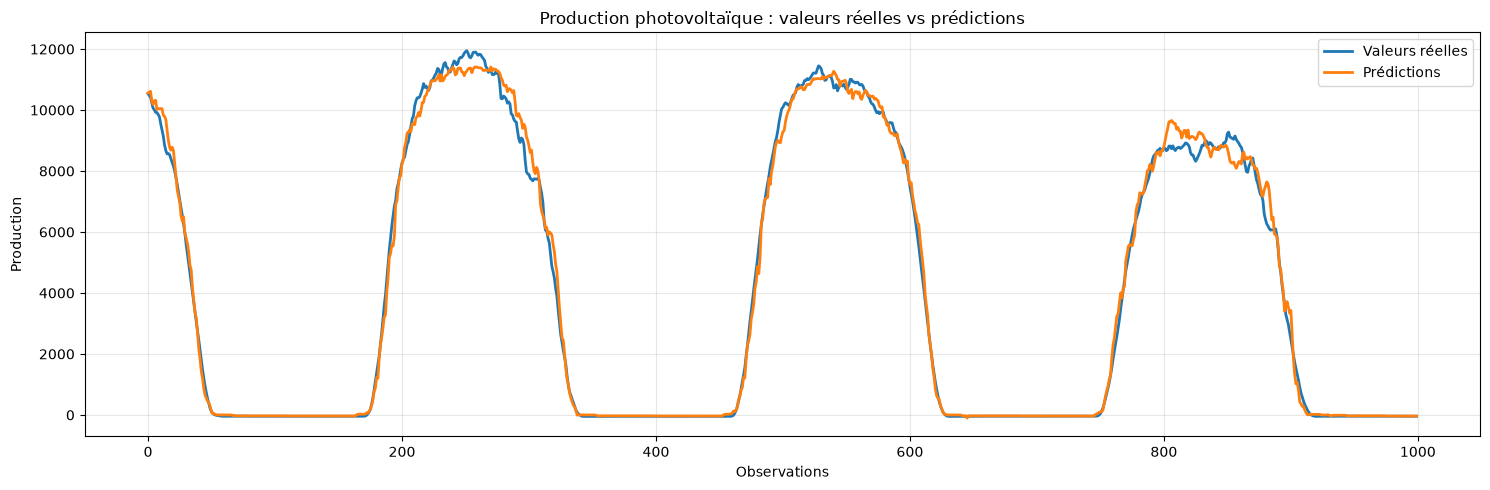

In [43]:
plot_predictions(
    y_test_pv,
    pred_test_pv,
    "Production photovoltaïque : valeurs réelles vs prédictions",
    "Production",
    "pv_prediction_vs_real.png"
)

# 14.3 Production éolienne

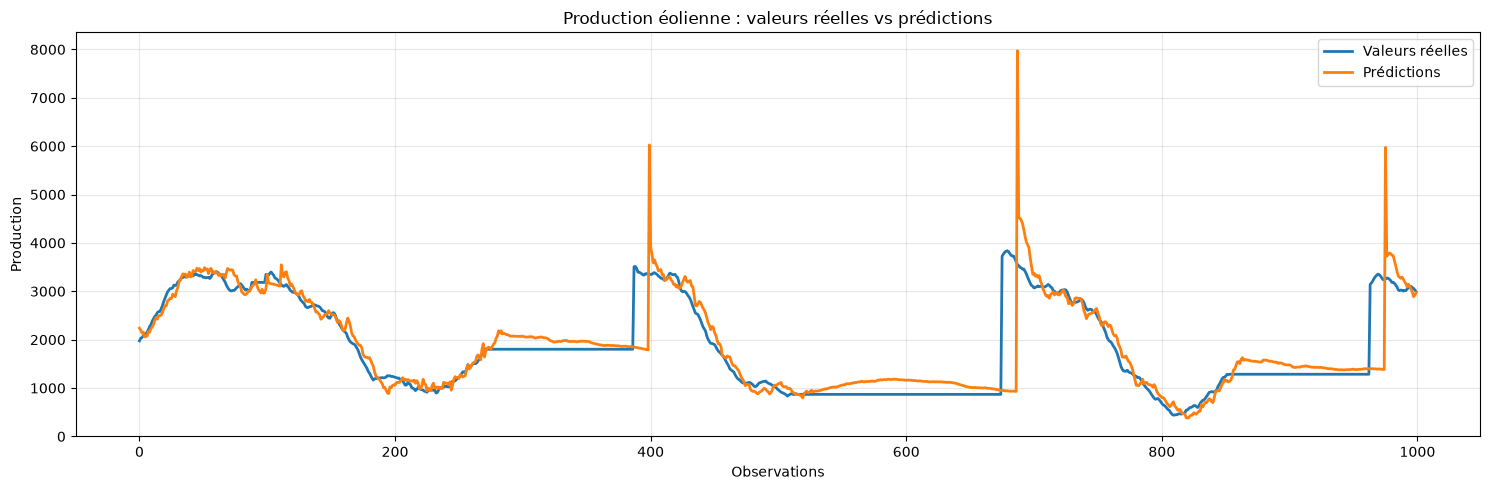

In [44]:
plot_predictions(
    y_test_wind,
    pred_test_wind,
    "Production éolienne : valeurs réelles vs prédictions",
    "Production",
    "wind_prediction_vs_real.png"
)

# 14.4 Demande électrique

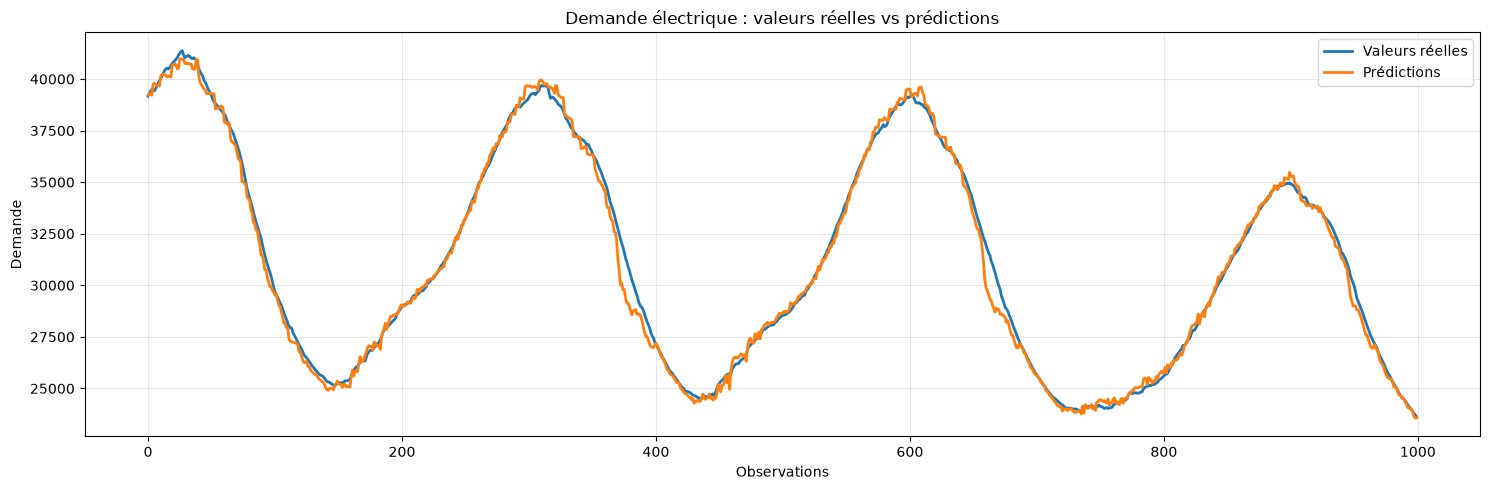

In [45]:
plot_predictions(
    y_test_demand,
    pred_test_demand,
    "Demande électrique : valeurs réelles vs prédictions",
    "Demande",
    "demand_prediction_vs_real.png"
)

# 15. Analyse des résidus (erreurs)

Les résidus correspondent à la différence entre les valeurs observées et les
valeurs prédites.

Une distribution centrée autour de zéro indique que le modèle ne présente pas
de biais systématique et fournit des prédictions globalement équilibrées.

In [46]:
# FONCTION D'AFFICHAGE DES RÉSIDUS

def plot_residuals(
    y_true,
    y_pred,
    title,
    filename
):

    residuals = y_true.values - y_pred

    plt.figure(figsize=(8,5))

    plt.hist(
        residuals,
        bins=50,
        edgecolor="black"
    )

    plt.axvline(
        0,
        color="red",
        linestyle="--"
    )

    plt.title(title)

    plt.xlabel("Erreur")

    plt.ylabel("Fréquence")

    plt.grid(alpha=0.3)

    plt.tight_layout()

    plt.savefig(
        FIGURES_DIR / filename,
        dpi=300,
        bbox_inches="tight"
    )

    plt.show()

# 15.1 Photovoltaïque

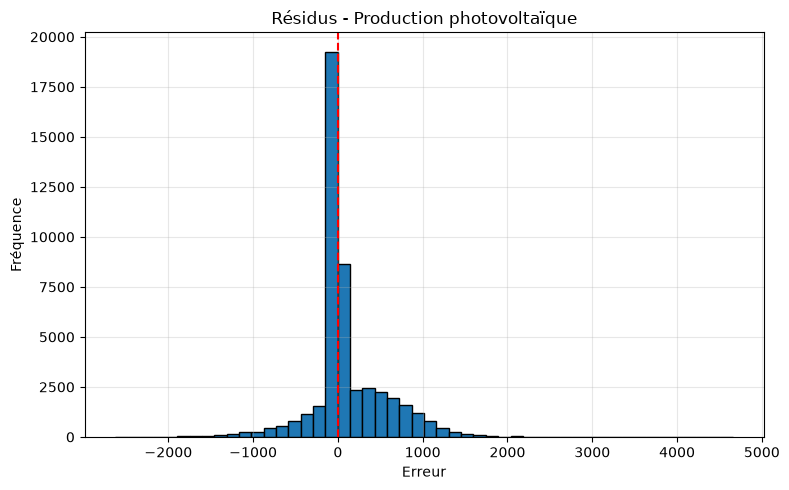

In [47]:
plot_residuals(
    y_test_pv,
    pred_test_pv,
    "Résidus - Production photovoltaïque",
    "pv_residuals.png"
)

# 15.2 Éolien

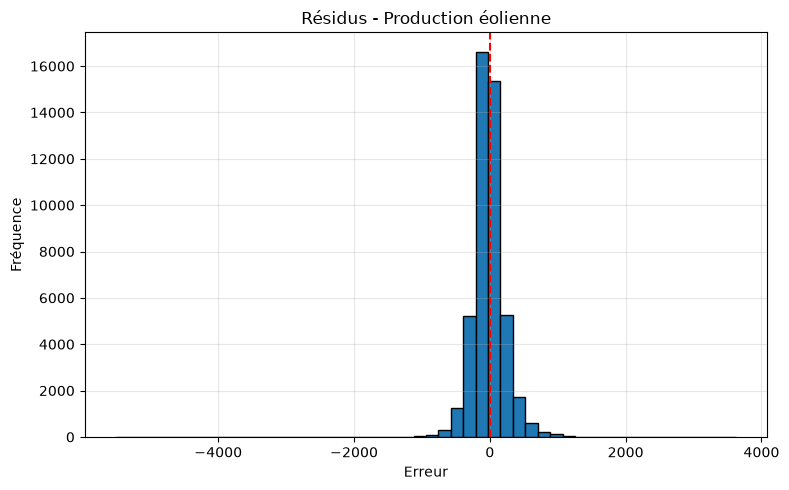

In [48]:
plot_residuals(
    y_test_wind,
    pred_test_wind,
    "Résidus - Production éolienne",
    "wind_residuals.png"
)

# 15.3 Demande

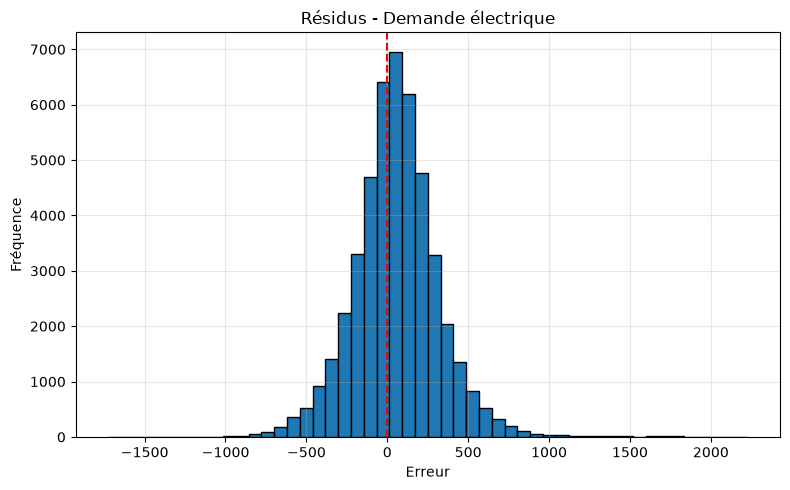

In [49]:
plot_residuals(
    y_test_demand,
    pred_test_demand,
    "Résidus - Demande électrique",
    "demand_residuals.png"
)

# 16. Discussion des résultats

L'évaluation sur l'ensemble de test confirme que les modèles sélectionnés lors
de la phase de validation conservent de bonnes performances sur des données
jamais utilisées pendant l'entraînement.

Le modèle HistGradientBoosting obtient les meilleurs résultats pour la
production photovoltaïque et la demande électrique, ce qui montre sa capacité à
modéliser les relations non linéaires entre les variables météorologiques,
temporelles et énergétiques.

Pour la production éolienne, la régression linéaire présente les meilleures
performances. Ce résultat suggère que les variables explicatives construites
lors du Feature Engineering permettent déjà de capturer une grande partie des
relations existantes sans nécessiter un modèle plus complexe.

Les graphiques comparant les valeurs observées aux prédictions montrent une
bonne superposition des courbes, tandis que les distributions des résidus sont
globalement centrées autour de zéro, ce qui indique l'absence de biais
systématique important dans les prédictions.

# 17. Sauvegarde des figures

In [50]:
# 17. VÉRIFICATION DES FIGURES

figure_files = [
    "pv_prediction_vs_real.png",
    "wind_prediction_vs_real.png",
    "demand_prediction_vs_real.png",
    "pv_residuals.png",
    "wind_residuals.png",
    "demand_residuals.png"
]

for file in figure_files:
    path = FIGURES_DIR / file
    print(f"{file} : {'OK' if path.exists() else 'MANQUANT'}")

pv_prediction_vs_real.png : OK
wind_prediction_vs_real.png : OK
demand_prediction_vs_real.png : OK
pv_residuals.png : OK
wind_residuals.png : OK
demand_residuals.png : OK


# 18 Préparation des données pour Power BI

Cette section regroupe les observations réelles, les prédictions finales et
les erreurs associées dans un fichier unique.

Ce fichier sera utilisé pour construire le dashboard décisionnel Power BI.

In [51]:
# 18. PRÉPARATION DES DONNÉES POUR POWER BI

powerbi_df = pd.DataFrame({
    "Time": energy_df.loc[X_test.index, "Time"].values,

    "PV_reel": y_test_pv.values,
    "PV_predit": pred_test_pv,
    "PV_erreur": y_test_pv.values - pred_test_pv,

    "Wind_reel": y_test_wind.values,
    "Wind_predit": pred_test_wind,
    "Wind_erreur": y_test_wind.values - pred_test_wind,

    "Demand_reel": y_test_demand.values,
    "Demand_predit": pred_test_demand,
    "Demand_erreur": y_test_demand.values - pred_test_demand
})

powerbi_df["Year"] = pd.to_datetime(
    powerbi_df["Time"]
).dt.year

powerbi_df["Month"] = pd.to_datetime(
    powerbi_df["Time"]
).dt.month

powerbi_df["Day"] = pd.to_datetime(
    powerbi_df["Time"]
).dt.day

powerbi_df["Hour"] = pd.to_datetime(
    powerbi_df["Time"]
).dt.hour

powerbi_df["Weekday"] = pd.to_datetime(
    powerbi_df["Time"]
).dt.day_name()

display(powerbi_df.head())

print("Dimensions :", powerbi_df.shape)

,Time,PV_reel,PV_predit,PV_erreur,Wind_reel,Wind_predit,Wind_erreur,Demand_reel,Demand_predit,Demand_erreur,Year,Month,Day,Hour,Weekday
0,2021-07-21 14:45:00,10535.000,10562.036,-27.036,1975.000,2236.896,-261.896,39163.000,39220.329,-57.329,2021,7,21,14,Wednesday
1,2021-07-21 14:50:00,10477.000,10590.855,-113.855,2029.000,2195.641,-166.641,39299.000,39305.370,-6.370,2021,7,21,14,Wednesday
2,2021-07-21 14:55:00,10413.000,10611.317,-198.317,2044.000,2139.664,-95.664,39410.000,39257.723,152.277,2021,7,21,14,Wednesday
3,2021-07-21 15:00:00,10227.000,10278.301,-51.301,2082.000,2157.538,-75.538,39506.000,39216.441,289.559,2021,7,21,15,Wednesday
4,2021-07-21 15:05:00,10059.000,10183.435,-124.435,2105.000,2055.432,49.568,39431.000,39749.364,-318.364,2021,7,21,15,Wednesday


Dimensions : (47043, 15)


In [52]:
# 19. SAUVEGARDE POUR POWER BI

POWERBI_FILE = (
    RESULTS_DIR
    / "powerbi_predictions.csv"
)

powerbi_df.to_csv(
    POWERBI_FILE,
    index=False
)

print("Fichier Power BI sauvegardé :", POWERBI_FILE)
print("Existe :", POWERBI_FILE.exists())

Fichier Power BI sauvegardé : c:\Users\celes\Desktop\PFE\results\powerbi_predictions.csv
Existe : True


# Conclusion du Notebook 06

Ce notebook a permis d'évaluer les modèles sélectionnés lors de la phase de
validation sur un ensemble de test indépendant.

Les principales réalisations sont les suivantes :

- chargement des modèles sauvegardés ;
- reconstruction du jeu de test ;
- calcul des performances finales (MAE, RMSE et R²) ;
- comparaison entre les valeurs observées et les prédictions ;
- analyse des résidus ;
- sauvegarde des résultats et des figures.

Les performances obtenues montrent que les modèles sélectionnés généralisent
correctement sur des données inédites.

Ces modèles constituent désormais la base du système de prédiction énergétique
et seront intégrés dans le dashboard interactif développé dans le Notebook 07.